In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
def clean_ridership(filename):
    
    # Loads file
    file = pd.read_csv(filename, low_memory=False)

    file = file.dropna()
    
    file['total_boardings'] = file['boardings'] * file['sample_size']
    file['total_alightings'] = file['alightings'] * file['sample_size']

    return file.drop(['boardings', 'alightings', 'sample_size'], axis=1)

In [4]:
df = clean_ridership('MBTA_Bus_Ridership_Fall_2019.csv')
df[(df['route_id'] == '1')]

,season,route_id,route_variant,direction_id,trip_start_time,day_type_id,day_type_name,stop_name,stop_id,stop_sequence,load_,ObjectId,total_boardings,total_alightings
0,Fall 2019,1,1-0-0,0,04:37:00,day_type_01,weekday,MASSACHUSETTS AVE @ TROWBRIDG,108,23,4.6,2588430,0.0,71.5
1,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ TROWBRIDG,108,23,3.4,2588432,25.6,0.0
2,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ BOW ST,109,24,3.4,2588466,0.0,0.0
3,Fall 2019,1,1-0-0,0,04:37:00,day_type_01,weekday,MASSACHUSETTS AVE @ BOW ST,109,24,4.2,2588471,0.0,26.0
4,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ HOLYOKE S,110,25,0.4,2588472,0.0,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16491,Fall 2019,1,1-0-1,1,25:12:00,day_type_01,weekday,MASSACHUSETTS AVE @ HUNTINGTO,82,17,3.3,2605184,3.6,3.6
16492,Fall 2019,1,1-0-1,1,25:12:00,day_type_01,weekday,MASSACHUSETTS AVE @ COLUMBUS,83,19,3.4,2605185,3.6,3.6
16493,Fall 2019,1,1-0-1,1,25:12:00,day_type_01,weekday,MASSACHUSETTS AVE @ TREMONT S,84,20,3.4,2605186,3.6,3.6
16494,Fall 2019,1,1-0-1,1,25:12:00,day_type_01,weekday,MASSACHUSETTS AVE @ HARRISON,854,22,3.1,2605187,3.6,10.8


In [5]:
df['direction_id'].value_counts()

direction_id
1    432007
0    431033
Name: count, dtype: int64

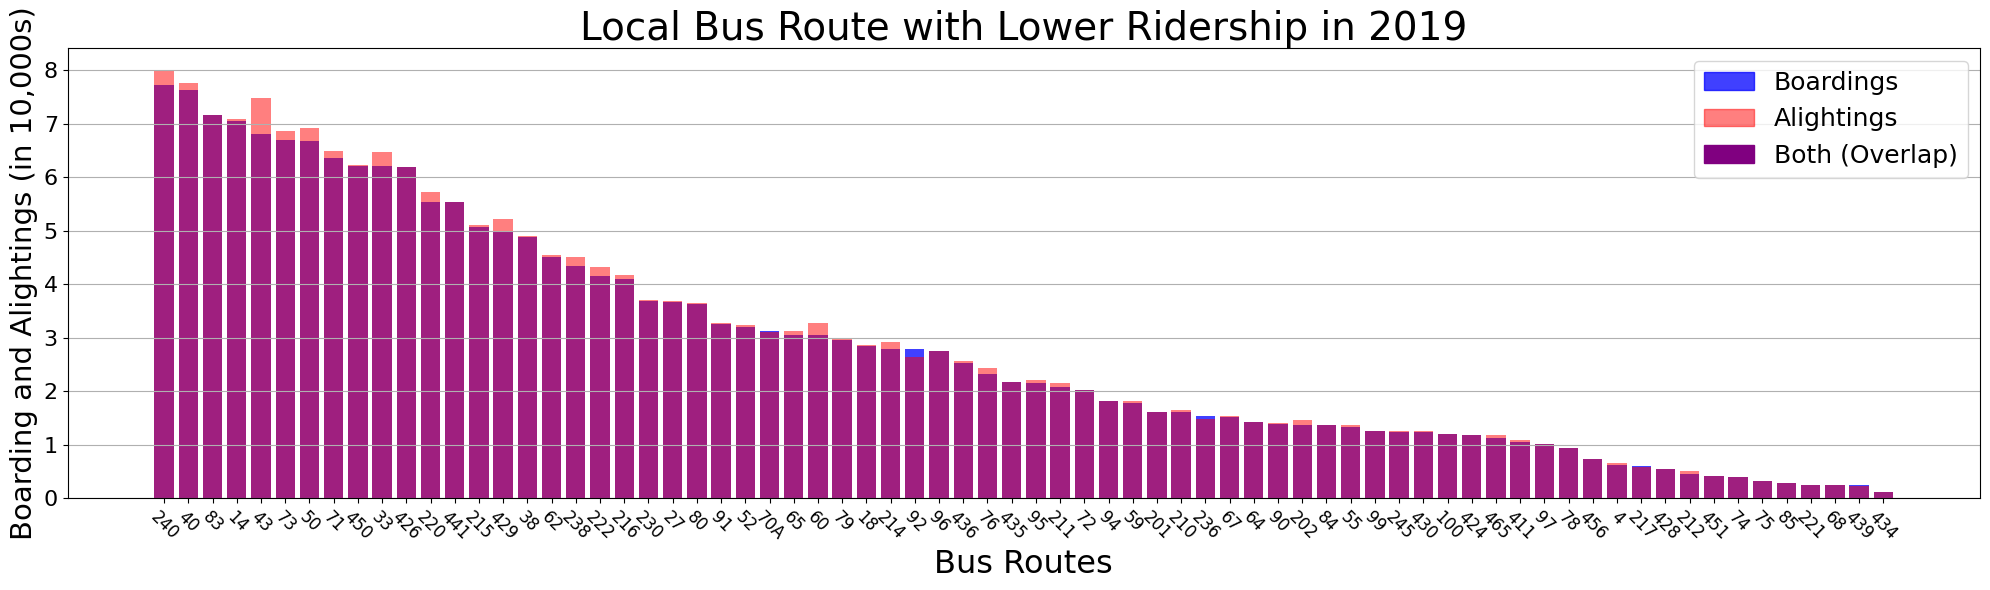

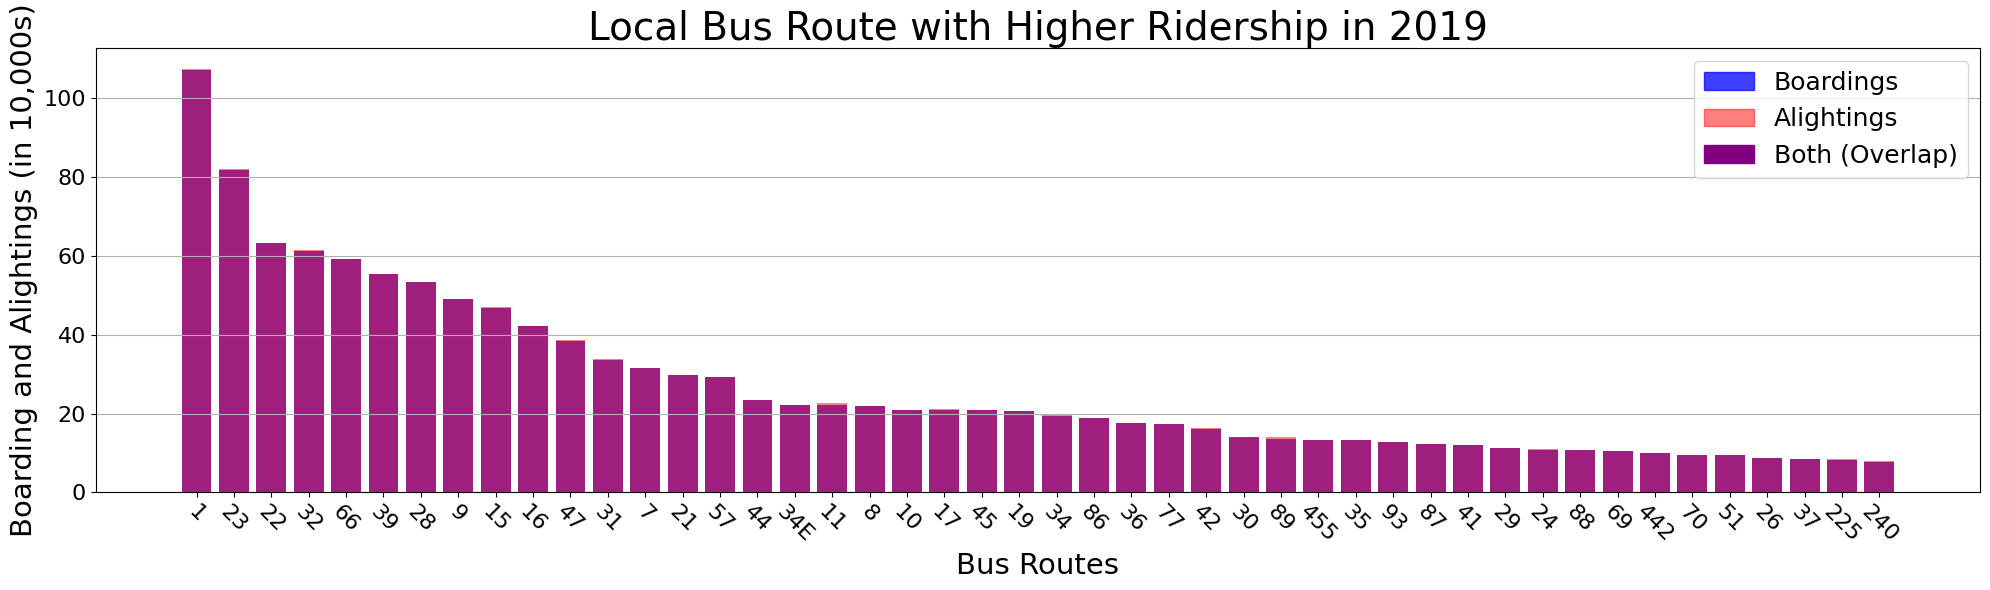

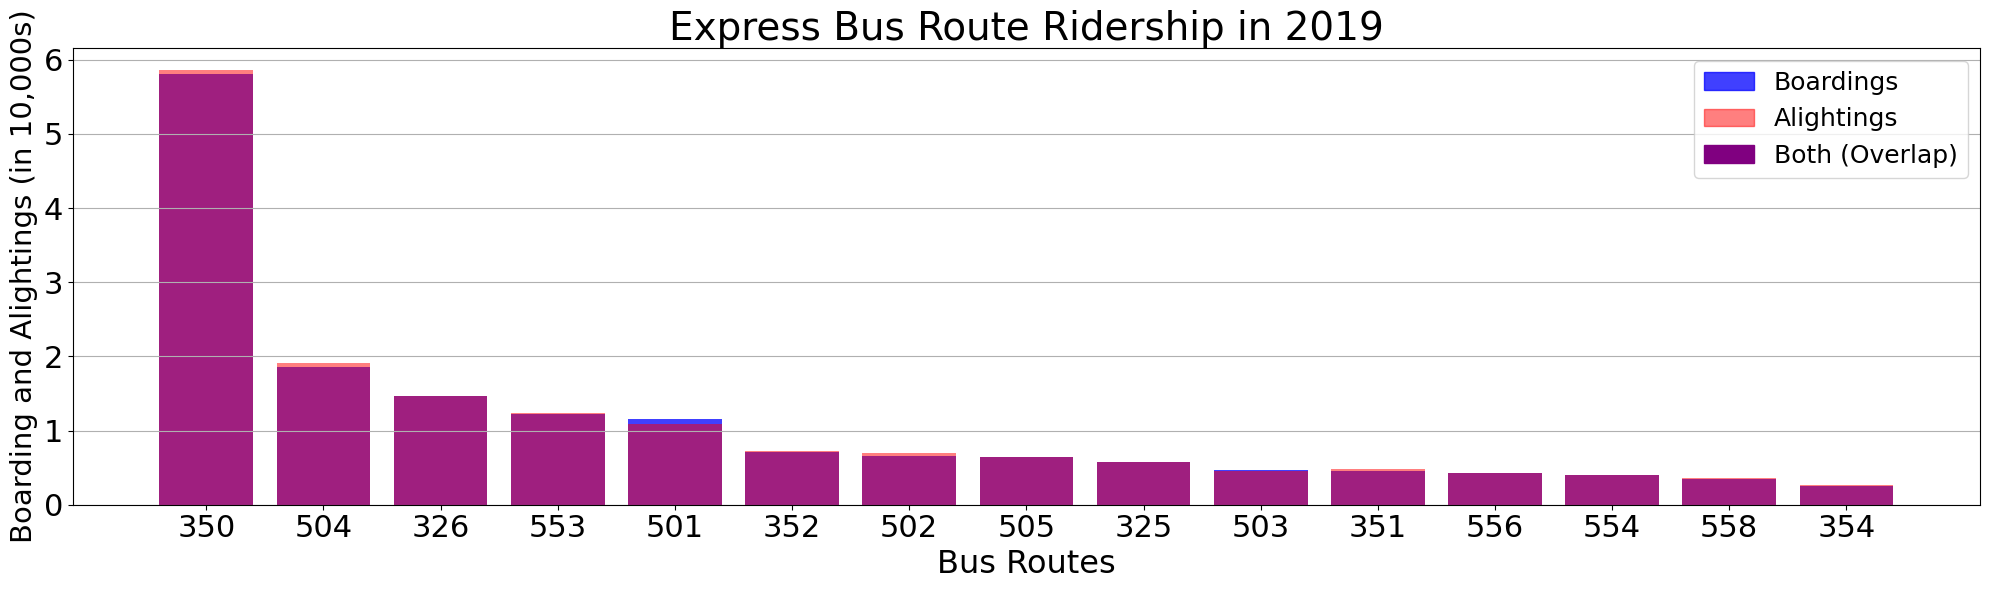

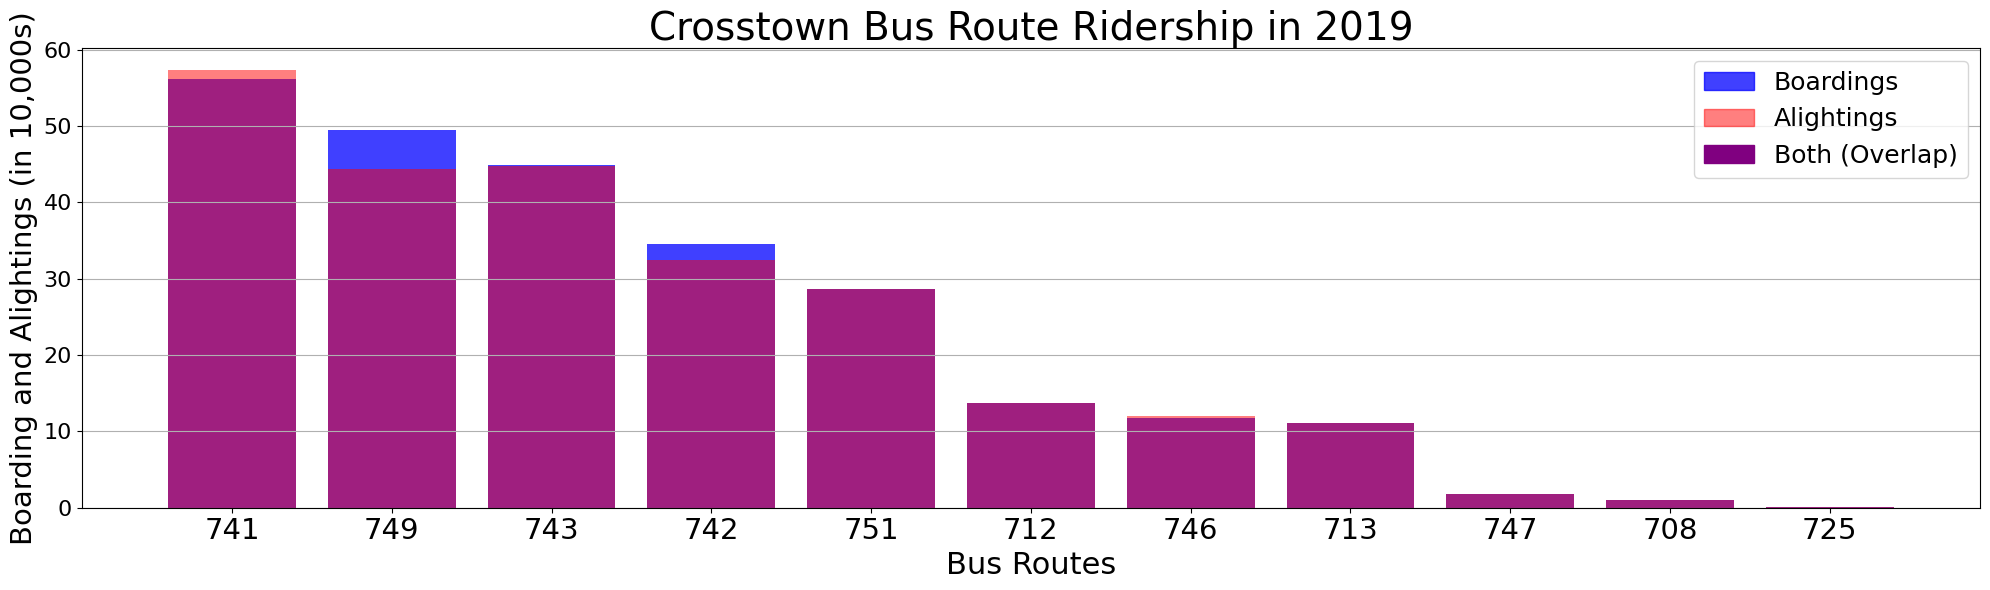

In [8]:
# Loads file
df = clean_ridership('MBTA_Bus_Ridership_Fall_2019.csv')

routes = np.unique(df['route_id'])

local_routes = []
express_routes = []
crosstown = []
limited_express_400s = [426, 428, 441, 442, 450, 455, 456]

for route in routes:
    # Convert to int if possible, otherwise keep it as a string for cases like '34E' or '70A'
    try:
        route_num = int(route)
    except ValueError:
        route_num = route  # Keep as is if not convertible

    if isinstance(route_num, int):
        if 1 <= route_num <= 100:
            local_routes.append(route)
        elif 200 <= route_num <= 299:
            local_routes.append(route)  # 200s considered local
        elif 300 <= route_num <= 399:
            express_routes.append(route)  # 300s considered express
        elif 400 <= route_num <= 499:
            if route in limited_express_400s:
                express_routes.append(route)  # Specific 400s as express
            else:
                local_routes.append(route) # Rest considered local
        elif 500 <= route_num <= 599:
            express_routes.append(route)
        elif 700 <= route_num <= 799:
            crosstown.append(route)
    else:
        # Include any other routes that are not numerical number
        if isinstance(route, str):
            local_routes.append(route)
            
local = df[df['route_id'].isin(local_routes)]
express = df[df['route_id'].isin(express_routes)]
ct = df[df['route_id'].isin(crosstown)]

#Calculates boardings and alightings by bus routes
local_ridership_by_stop = local.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
local_ridership_by_stop["difference"] = local_ridership_by_stop['total_boardings'] - local_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
express_ridership_by_stop = express.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
express_ridership_by_stop["difference"] = express_ridership_by_stop['total_boardings'] - express_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
ct_ridership_by_stop = ct.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
ct_ridership_by_stop["difference"] = ct_ridership_by_stop['total_boardings'] - ct_ridership_by_stop['total_alightings']

lower_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] <= 80000) | 
    (local_ridership_by_stop['total_alightings'] <= 80000)
]

higher_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] > 80000) | 
    (local_ridership_by_stop['total_alightings'] > 80000)
]

# Lower Local Bus Route Ridership Bar Chart
sorted_lower_local_ridership = lower_local_low_ridership.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_lower_local_ridership.index.astype(str), sorted_lower_local_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_lower_local_ridership.index.astype(str), sorted_lower_local_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route with Lower Ridership in 2019", fontsize=28)  # Larger title font
plt.xlabel("Bus Routes", fontsize=23)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=-45, fontsize=12)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Higher Local Bus Route Ridership Bar Chart
sorted_higher_local_ridership = higher_local_low_ridership.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_higher_local_ridership.index.astype(str), sorted_higher_local_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_higher_local_ridership.index.astype(str), sorted_higher_local_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route with Higher Ridership in 2019", fontsize=28)  # Larger title font
plt.xlabel("Bus Routes", fontsize=21)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=-45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Express Bus Route Ridership Bar Chart
sorted_express_ridership = express_ridership_by_stop.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_express_ridership.index.astype(str), sorted_express_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_express_ridership.index.astype(str), sorted_express_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Express Bus Route Ridership in 2019", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=23)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=0, fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Crosstown Bus Route Ridership Bar Chart
sorted_ct_ridership = ct_ridership_by_stop.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_ct_ridership.index.astype(str), sorted_ct_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_ct_ridership.index.astype(str), sorted_ct_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Crosstown Bus Route Ridership in 2019", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=22)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=0, fontsize=21)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

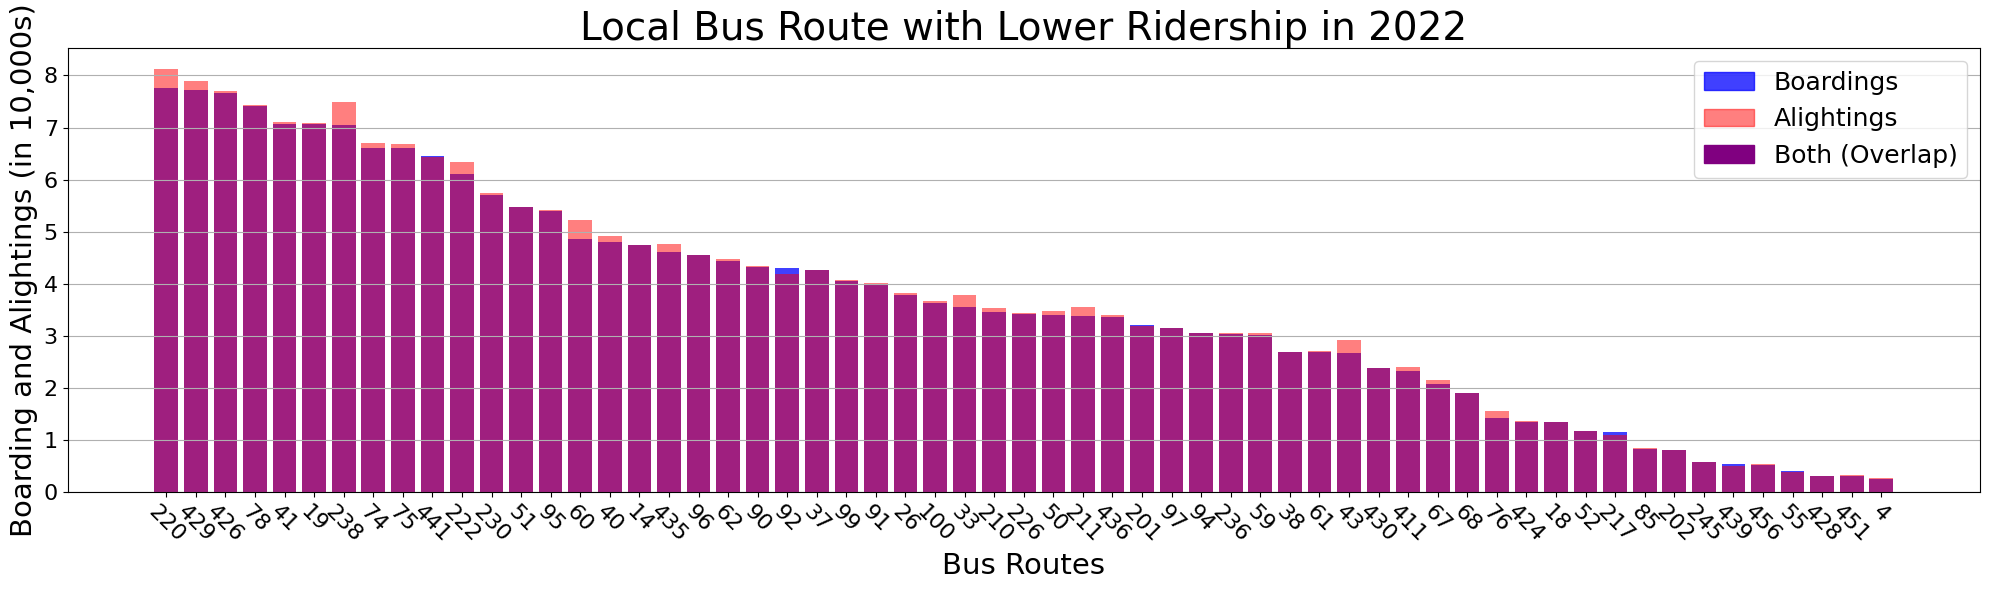

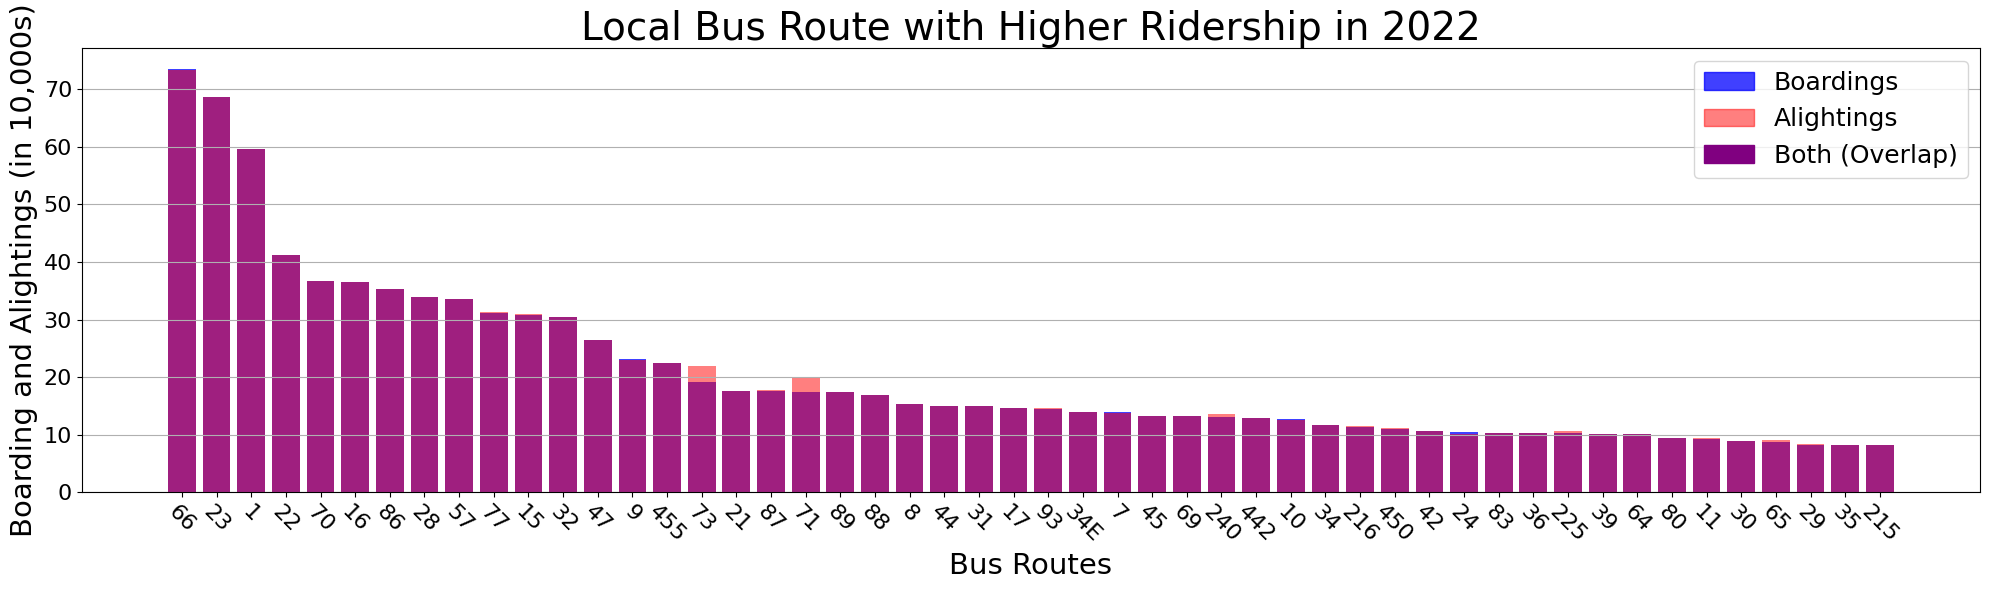

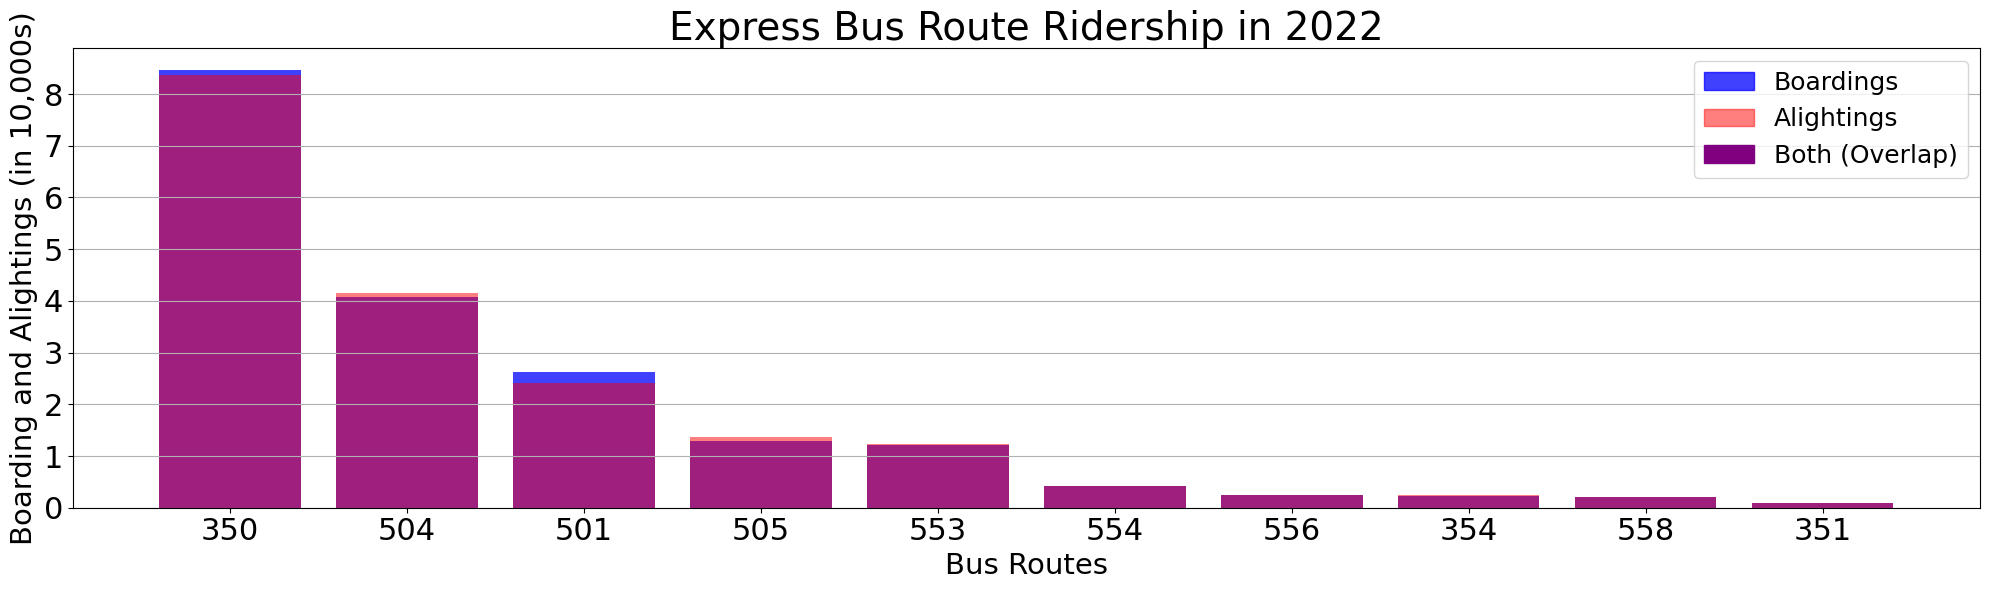

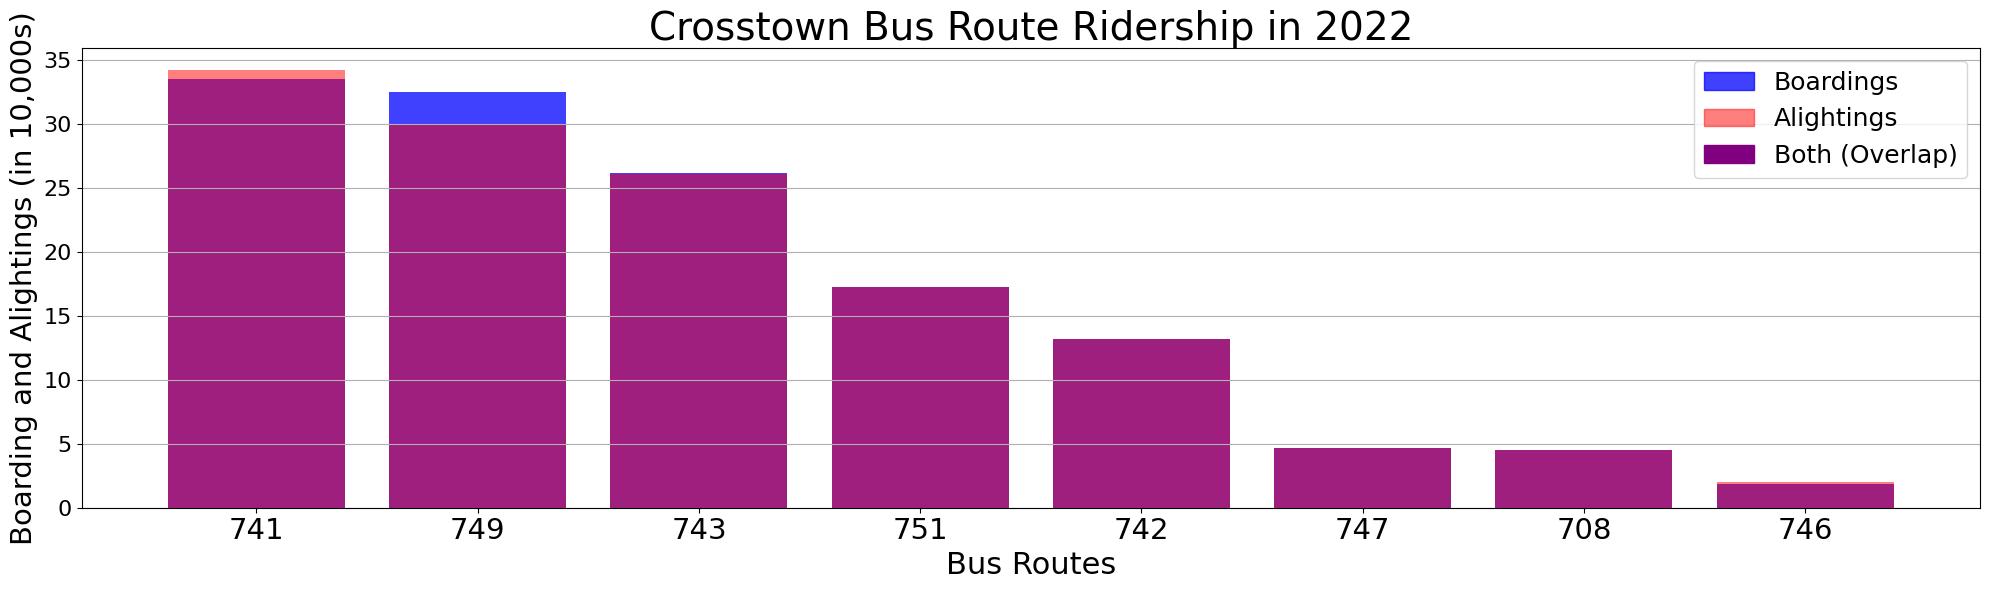

In [7]:
# Loads file
df = clean_ridership('MBTA_Bus_Ridership_Fall_2022.csv')

routes = np.unique(df['route_id'])

local_routes = []
express_routes = []
crosstown = []
limited_express_400s = [426, 428, 441, 442, 450, 455, 456]

for route in routes:
    # Convert to int if possible, otherwise keep it as a string for cases like '34E' or '70A'
    try:
        route_num = int(route)
    except ValueError:
        route_num = route  # Keep as is if not convertible

    if isinstance(route_num, int):
        if 1 <= route_num <= 100:
            local_routes.append(route)
        elif 200 <= route_num <= 299:
            local_routes.append(route)  # 200s considered local
        elif 300 <= route_num <= 399:
            express_routes.append(route)  # 300s considered express
        elif 400 <= route_num <= 499:
            if route in limited_express_400s:
                express_routes.append(route)  # Specific 400s as express
            else:
                local_routes.append(route) # Rest considered local
        elif 500 <= route_num <= 599:
            express_routes.append(route)
        elif 700 <= route_num <= 799:
            crosstown.append(route)
    else:
        # Include any other routes that are not numerical number
        if isinstance(route, str):
            local_routes.append(route)
            
local = df[df['route_id'].isin(local_routes)]
express = df[df['route_id'].isin(express_routes)]
ct = df[df['route_id'].isin(crosstown)]

#Calculates boardings and alightings by bus routes
local_ridership_by_stop = local.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
local_ridership_by_stop["difference"] = local_ridership_by_stop['total_boardings'] - local_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
express_ridership_by_stop = express.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
express_ridership_by_stop["difference"] = express_ridership_by_stop['total_boardings'] - express_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
ct_ridership_by_stop = ct.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
ct_ridership_by_stop["difference"] = ct_ridership_by_stop['total_boardings'] - ct_ridership_by_stop['total_alightings']

lower_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] <= 80000) | 
    (local_ridership_by_stop['total_alightings'] <= 80000)
]

higher_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] > 80000) & 
    (local_ridership_by_stop['total_alightings'] > 80000)
]

# Lower Local Bus Route Ridership Bar Chart
sorted_lower_local_ridership = lower_local_low_ridership.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_lower_local_ridership.index.astype(str), sorted_lower_local_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_lower_local_ridership.index.astype(str), sorted_lower_local_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route with Lower Ridership in 2022", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=21)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=-45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Higher Local Bus Route Ridership Bar Chart
sorted_higher_local_ridership = higher_local_low_ridership.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_higher_local_ridership.index.astype(str), sorted_higher_local_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_higher_local_ridership.index.astype(str), sorted_higher_local_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route with Higher Ridership in 2022", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=21)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=-45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Express Bus Route Ridership Bar Chart
sorted_express_ridership = express_ridership_by_stop.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_express_ridership.index.astype(str), sorted_express_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_express_ridership.index.astype(str), sorted_express_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Express Bus Route Ridership in 2022", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=21)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=0, fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Crosstown Bus Route Ridership Bar Chart
sorted_ct_ridership = ct_ridership_by_stop.sort_values(by='total_boardings', ascending=False)
plt.figure(figsize=(20, 6))
plt.bar(sorted_ct_ridership.index.astype(str), sorted_ct_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(sorted_ct_ridership.index.astype(str), sorted_ct_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Crosstown Bus Route Ridership in 2022", fontsize=28)  # Updated title to 2022
plt.xlabel("Bus Routes", fontsize=22)
plt.ylabel("Boarding and Alightings (in 10,000s)", fontsize=21)
plt.xticks(rotation=0, fontsize=21)
plt.yticks(fontsize=16)
plt.tight_layout()
boardings_patch = mpatches.Patch(color='blue', alpha=0.75, label='Boardings')
alightings_patch = mpatches.Patch(color='red', alpha=0.5, label='Alightings')
both_patch = mpatches.Patch(color='purple', label='Both (Overlap)')
plt.legend(handles=[boardings_patch, alightings_patch, both_patch], fontsize=18)
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()